In [21]:
# pip install openpyxl

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.lines import Line2D
from typing import Literal
from sklearn.decomposition import PCA

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

from support_dea import (
    prepare_count_matrix,
    sample_overview_data_wrangling,
    gene_ensemble_id_mapping,
)

# Data prep

In [2]:
METADATA_PATH = f"{os.getcwd()}/../../../hgsoc_data_detective/"
DATA_PATH = f"{os.getcwd()}/../../../alignment_results/"
GTF_PATH = (
    f"{os.getcwd()}/../../../../../Downloads/refdata-gex-GRCh38-2024-A/genes/genes.gtf"
)

In [3]:
gtf = gene_ensemble_id_mapping(GTF_PATH)

In [4]:
gtf[:5]

[('ENSG00000185238', 'PRMT3'),
 ('ENSG00000258813', 'RBM25-AS1'),
 ('ENSG00000251376', 'ENSG00000251376'),
 ('ENSG00000223461', 'ENSG00000223461'),
 ('ENSG00000168306', 'ACOX2')]

In [5]:
DATA_TYPE = "Dissociated Bulk"  # Bulk or Dissociated Bulk

In [6]:
sample_df = sample_overview_data_wrangling(METADATA_PATH, DATA_TYPE)

In [7]:
sample_df.head()

,Site of origin,Long Sample ID
Sample #,,
2018,Omentum,230414/2018
2483,Unknown,230414/2483
2477,Unknown,230414/2477
2460,Omentum,230414/2460
2416,Ovary,230414/2416


In [8]:
sample_df["Site of origin"].value_counts()

Site of origin
Unknown                   15
Omentum                   10
Ovary                      5
Para-colic gutter          1
Para-aortic lymph node     1
Name: count, dtype: int64

In [9]:
count_matrix = prepare_count_matrix(DATA_PATH)

# Select only bulk / diss bulk samples
if DATA_TYPE == "Bulk":
    count_matrix = count_matrix[~count_matrix.index.str.contains("2304")]
elif DATA_TYPE == "Dissociated Bulk":
    count_matrix = count_matrix[count_matrix.index.str.contains("2304")]

# Only consider genes that have more than 10 read counts in total
count_matrix = count_matrix[count_matrix.columns[count_matrix.sum(axis=0) >= 10]]

# Add "site of origin" from sample_df
count_matrix.index.name = "Long Sample ID"
count_df = pd.merge(
    sample_df,
    count_matrix,
    how="inner",
    left_on="Long Sample ID",
    right_on="Long Sample ID",
)
count_df = count_df.set_index("Long Sample ID")

In [10]:
# Only consider ovary and omentum samples
count_df = count_df[
    (count_df["Site of origin"] == "Omentum") | (count_df["Site of origin"] == "Ovary")
]

In [13]:
count_df.to_csv(f"../data/count_matrix_{DATA_TYPE}_site.csv")

In [14]:
count_df.head()

,Site of origin,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000291299,ENSG00000291300,ENSG00000291309,ENSG00000291317,ENSG00000291326,ENSG00000291342,ENSG00000292223,ENSG00000292246,ENSG00000292271,ENSG00000292309
Long Sample ID,,,,,,,,,,,,,,,,,,,,,
230414/2018,Omentum,485,1,1400,86,78,845,2036,843,376,...,426,15,9,47,0,4,1,0,1,2
230414/2460,Omentum,499,3,836,88,77,417,3003,548,338,...,177,117,5,204,0,1,0,0,0,0
230414/2416,Ovary,466,11,402,122,79,465,384,359,188,...,151,7,0,38,0,0,0,0,6,12
230414/2278,Omentum,557,3,3726,340,209,712,2999,912,480,...,833,158,43,678,1,8,1,1,1,0
230414/2249,Ovary,430,4,1119,311,216,541,3651,1355,308,...,334,18,5,97,0,1,0,0,0,0


In [44]:
count_df.rename(columns={"Site of origin": "site"}, inplace=True)

# DEA with deseq2

In [21]:
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=count_df.drop(columns=["site"]),
    metadata=count_df[["site", "ENSG00000000003"]],
    design="~site",
    refit_cooks=True,
    inference=inference,
)
dds.deseq2()

stat_res = DeseqStats(
    dds, 
    contrast=["site", "Omentum", "Ovary"],
    inference=inference,
)
stat_res.summary()
res = stat_res.results_df.rename(index=dict(gtf))

# Set some threshold to only retain genes that are signficantly DE
de_genes_df = res[
    ((res["padj"] < 0.05) & (abs(res["log2FoldChange"]) > 0.5) & (res["baseMean"] > 10))
]

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.89 seconds.

Fitting dispersion trend curve...
... done in 0.23 seconds.

Fitting MAP dispersions...
... done in 2.21 seconds.

Fitting LFCs...
... done in 1.25 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 1233 outlier genes.

Fitting dispersions...
... done in 0.09 seconds.

Fitting MAP dispersions...
... done in 0.10 seconds.

Fitting LFCs...
... done in 0.09 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: site Omentum vs Ovary
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000000003   366.756933       -0.077917  0.467364 -0.166716  0.867594   
ENSG00000000005     8.359633       -0.405498  0.648817 -0.624980  0.531984   
ENSG00000000419  1491.226230       -0.446539  0.320583 -1.392895  0.163652   
ENSG00000000457   149.612318        0.208430  0.398193  0.523440  0.600668   
ENSG00000000460   118.481984        0.062807  0.408845  0.153620  0.877909   
...                      ...             ...       ...       ...       ...   
ENSG00000291342     1.059014       -0.109792  1.870266 -0.058704  0.953188   
ENSG00000292223     1.557657        0.062063  1.113681  0.055728  0.955559   
ENSG00000292246     1.006060       -1.226760  1.187684 -1.032901  0.301650   
ENSG00000292271     0.337331        0.667889  2.769011  0.241201  0.809399   
ENSG00000292309     3.141928        0.945252  1.235006  0.765382  0.444044   

   

... done in 0.52 seconds.



In [24]:
res["rank"] = -np.log10(res["padj"])*res["log2FoldChange"]

In [36]:
res.sort_values("rank", ascending=False).reset_index(drop=False)["index"].to_csv("../results/GOrilla_input_bulk_dea.csv", index=False, header=False)

In [229]:
de_genes_df.sort_values(by="log2FoldChange", key=abs, ascending=False).head(30)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
STAR,1042.375870,-6.308016,0.740325,-8.520601,1.587273e-17,3.676759e-13
LINC01391,33.064149,-5.934591,0.825985,-7.184867,6.727286e-13,7.791543e-09
PCDH11X,77.668997,-5.875874,0.883440,-6.651133,2.908450e-11,2.245711e-07
WIF1,17.268680,-4.957428,0.985374,-5.031013,4.878947e-07,6.278662e-04
IRS4,36.983801,-4.783443,0.932907,-5.127459,2.936784e-07,5.232898e-04
ENSG00000248935,16.328000,4.774394,1.048520,4.553460,5.277077e-06,4.365650e-03
PTPRT,547.900619,4.572006,1.013815,4.509704,6.491825e-06,4.556868e-03
KRTAP2-3,43.573226,4.324028,0.937853,4.610563,4.015797e-06,3.577766e-03
ADGRG4,14.879860,-4.322211,0.851217,-5.077686,3.820589e-07,6.278662e-04
ENPP6,18.278811,-4.008606,0.694570,-5.771347,7.864013e-09,2.602314e-05


In [230]:
res[res.index.str.contains("ADIPOQ")]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ADIPOQ,4.451354,1.079181,1.595648,0.676328,0.498833,NaN
ADIPOQ-AS1,0.381142,-1.368227,2.485710,-0.550437,0.582020,NaN


In [231]:
res[res.index.str.contains("CIDEC")]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
CIDEC,2.003167,2.671733,1.36577,1.95621,0.05044,NaN


In [232]:
res[res.index.str.contains("PLIN1")]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
PLIN1,14.427381,0.197001,0.631272,0.31207,0.754987,0.959426


# Volcano plot

In [233]:
adipocyte_markers_df = pd.read_excel("emont2022s1.xlsx", sheet_name="adipocyte markers", header=1).set_index("Unnamed: 0")
adipocyte_markers_df.index.name = None

In [234]:
de_genes_df[de_genes_df.index.isin(list(adipocyte_markers_df.index))].sort_values("padj")

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
PCSK6,169.448788,-2.594488,0.427311,-6.071658,1.265960e-09,0.000006
MME,140.174510,-2.386054,0.458660,-5.202228,1.969133e-07,0.000415
C1QB,1067.567397,2.355934,0.583152,4.040001,5.345107e-05,0.022929
RNF217-AS1,38.144004,-1.245789,0.310311,-4.014650,5.953403e-05,0.024380
CRNDE,310.567102,-2.095019,0.523868,-3.999131,6.357543e-05,0.024893
ACADL,35.350559,-2.909873,0.732250,-3.973881,7.071101e-05,0.026419
ANKRD36C,2054.900795,-0.744448,0.190995,-3.897734,9.709682e-05,0.029989
TMEFF2,17.259625,-2.446781,0.630635,-3.879869,1.045128e-04,0.030645
C1QA,901.652756,2.274480,0.589752,3.856674,1.149403e-04,0.032029
HLA-DRA,6761.786297,1.585437,0.413956,3.829968,1.281599e-04,0.032623


In [235]:
len(set(res.index) & set(adipocyte_markers_df.index))

1706

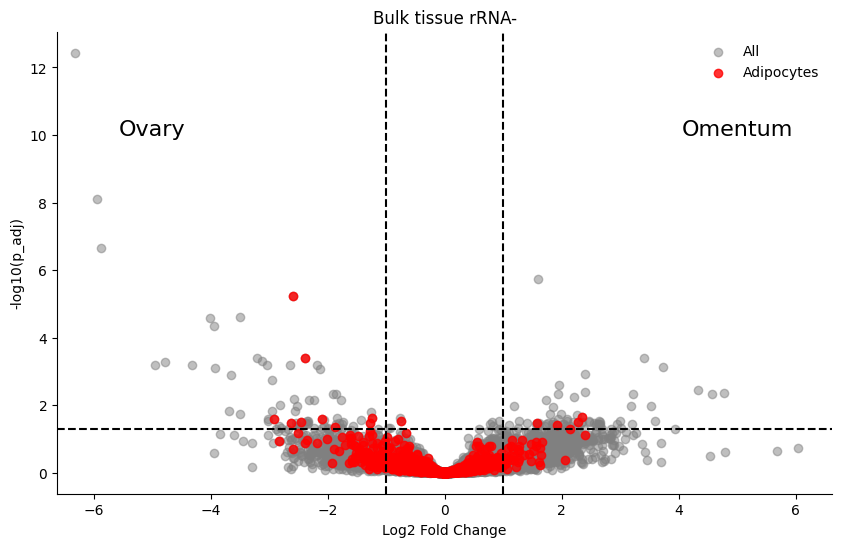

In [240]:
df = res.dropna(subset=["log2FoldChange", "padj"])
df = df[df["baseMean"] > 10]

# Create the volcano plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot all genes
plt.scatter(
    df['log2FoldChange'], -np.log10(df['padj']), 
    c='grey', 
    label='All', 
    alpha=0.5
    )

# # Plot adipocyte genes
plt.scatter(
    df[df.index.isin(list(adipocyte_markers_df.index))]["log2FoldChange"],
    -np.log10(df[df.index.isin(list(adipocyte_markers_df.index))]["padj"]),
    c='red', 
    label='Adipocytes', 
    alpha=0.8)

x_lim = abs(df["log2FoldChange"]).max()*1.05
plt.xlim([-x_lim, x_lim])

# # Add labels and title
plt.xlabel('Log2 Fold Change')
plt.ylabel('-log10(p_adj)')
plt.title(f"{DATA_TYPE} tissue rRNA-")

plt.text(-5, 10, "Ovary", size=16, ha="center")
plt.text(5, 10, "Omentum", size=16, ha="center")

# # Add horizontal line for significance threshold
plt.axhline(y=-np.log10(0.05), color='black', linestyle='--')

# # Add vertical lines for fold change threshold (optional)
plt.axvline(x=-1, color='black', linestyle='--')
plt.axvline(x=1, color='black', linestyle='--')

plt.legend(frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# for i, row in de_genes_df.iterrows():
#     ax.annotate(i, (row["log2FoldChange"]+0.1, -np.log10(row["padj"])+0.05))

In [241]:
figname = "volcano_plot_ovary_omentum_bulk_rrna-"
fig.savefig(figname + ".png", bbox_inches="tight")
fig.savefig(figname + ".pdf", bbox_inches="tight")

In [182]:
# de_genes_df.sort_values("padj").to_csv("de_genes_diss_bulk_polya+.csv", index=True)

In [243]:
de_genes_df[de_genes_df.index.isin(adipocyte_markers)].sort_values("padj")

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
PCSK6,169.448788,-2.594488,0.427311,-6.071658,1.265960e-09,0.000006
MME,140.174510,-2.386054,0.458660,-5.202228,1.969133e-07,0.000415
C1QB,1067.567397,2.355934,0.583152,4.040001,5.345107e-05,0.022929
RNF217-AS1,38.144004,-1.245789,0.310311,-4.014650,5.953403e-05,0.024380
CRNDE,310.567102,-2.095019,0.523868,-3.999131,6.357543e-05,0.024893
ACADL,35.350559,-2.909873,0.732250,-3.973881,7.071101e-05,0.026419
ANKRD36C,2054.900795,-0.744448,0.190995,-3.897734,9.709682e-05,0.029989
TMEFF2,17.259625,-2.446781,0.630635,-3.879869,1.045128e-04,0.030645
C1QA,901.652756,2.274480,0.589752,3.856674,1.149403e-04,0.032029
HLA-DRA,6761.786297,1.585437,0.413956,3.829968,1.281599e-04,0.032623
